# Customer Churn Prediction - Random Forest

This notebook implements the workflow for customer churn prediction with preprocessing, baseline and tuned Random Forest evaluation, and report-ready analysis.

## 1) Import Required Libraries

This section imports all required Python libraries for preprocessing, modeling, and evaluation.

In [24]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

## 2) Load Dataset

Include your public dataset URL in the report/submission file.

This section loads the churn dataset and performs an initial structure check.
Recommended report details: source link, context, number of rows/columns, feature meanings, and target distribution.

In [3]:
# 1) Load dataset
df = pd.read_csv('synthetic_customer_churn_100k.csv')

print('Shape:', df.shape)
display(df.head())
display(df.info())

Shape: (100000, 9)


,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


None

## 3) Basic Cleaning

This section drops non-predictive identifiers, ensures valid numeric types, and maps the target variable.

In [5]:
# 2) Basic cleaning
# Remove ID column because it is not predictive.
if 'CustomerID' in df.columns:
    df = df.drop(columns=['CustomerID'])

# Ensure numeric columns are numeric even if malformed rows exist.
numeric_cols = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Binary target mapping.
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print(df.isnull().sum())

Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64


## 4) Train-Test Split

This section separates features/target and creates stratified train-test data splits.

In [7]:
# 3) Train-test split
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

Train size: (80000, 7)
Test size : (20000, 7)


## 5) Preprocessing + Random Forest Pipeline (With Justification)

Why Random Forest for churn:
- Handles nonlinear relationships and mixed feature interactions well.
- Works well with tabular business data and is robust to noise.
- Provides feature importance for interpretability.
- Combined with class balancing, it can better handle class imbalance than many simple baselines.

In [9]:
# 4) Preprocessing + Random Forest pipeline
num_features = X_train.select_dtypes(include=['number']).columns.tolist()
cat_features = X_train.select_dtypes(exclude=['number']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])

model.fit(X_train, y_train)
print('Random Forest model trained successfully.')

Random Forest model trained successfully.


## 6) Baseline Evaluation

This section evaluates baseline Random Forest predictions using classification metrics.

In [11]:
# 5) Predictions and evaluation
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print('Random Forest Performance')
print('-' * 40)
print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1-score : {f1:.4f}')
print(f'ROC-AUC  : {auc:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Random Forest Performance
----------------------------------------
Accuracy : 0.7291
Precision: 0.6123
Recall   : 0.4986
F1-score : 0.5496
ROC-AUC  : 0.7877

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.77      0.84      0.81     13371
       Churn       0.61      0.50      0.55      6629

    accuracy                           0.73     20000
   macro avg       0.69      0.67      0.68     20000
weighted avg       0.72      0.73      0.72     20000



## 7) Confusion Matrix

This section visualizes classification outcomes with a confusion matrix heatmap.

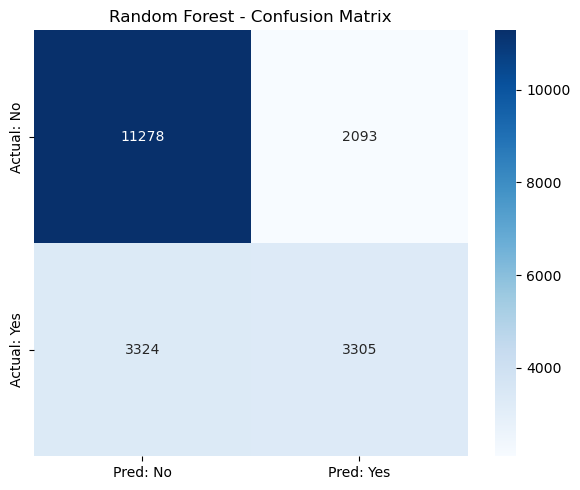

In [13]:
# 6) Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No', 'Pred: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

## 8) Feature Importance

This section highlights the most important input features learned by Random Forest.

,Feature,Importance
2,num__MonthlyCharges,0.290267
3,num__TotalCharges,0.218395
1,num__Tenure,0.199354
0,num__Age,0.145970
7,cat__Contract_Month-to-month,0.079650
8,cat__Contract_One year,0.024144
9,cat__Contract_Two year,0.019063
12,cat__PaymentMethod_Electronic check,0.003929
13,cat__PaymentMethod_Mailed check,0.003728
10,cat__PaymentMethod_Bank transfer,0.003429


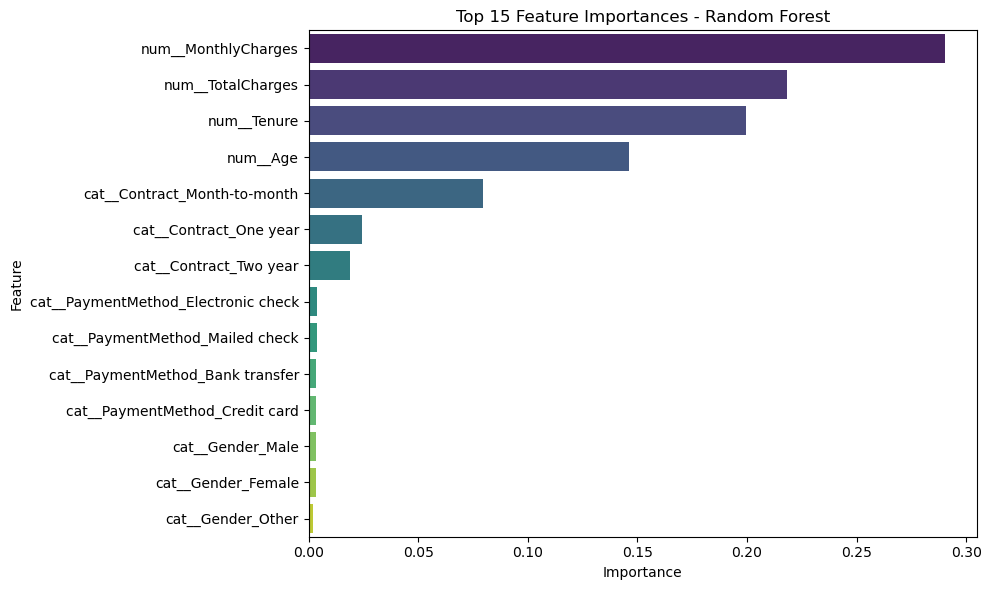

In [15]:
# 7) Feature importance (top 15)
preprocessor_fitted = model.named_steps['preprocessor']
rf_fitted = model.named_steps['classifier']

feature_names = preprocessor_fitted.get_feature_names_out()
importances = rf_fitted.feature_importances_

fi = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

display(fi)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

## 9) Hyperparameter Tuning (Randomized Search)

This step improves the Random Forest by searching across multiple hyperparameter combinations using cross-validation.

In [20]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import time

# Quick mode: tuned to finish in a few minutes on most laptops
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_distributions = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 8, 12],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__bootstrap': [True]
}

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=6,
    scoring='f1',
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

start_time = time.perf_counter()
search.fit(X_train, y_train)
elapsed_minutes = (time.perf_counter() - start_time) / 60

best_model = search.best_estimator_
print(f'Training time: {elapsed_minutes:.2f} minutes')
print('Best CV F1-score:', round(search.best_score_, 4))
print('Best Parameters:')
print(search.best_params_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Training time: 2.33 minutes
Best CV F1-score: 0.6199
Best Parameters:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 8, 'classifier__bootstrap': True}


## 10) Evaluate Tuned Model + ROC/PR Curves + Threshold Tuning

This gives stronger evaluation than plain accuracy and helps justify model decisions.

Tuned Random Forest Performance
----------------------------------------
Accuracy : 0.7514
Precision: 0.6256
Recall   : 0.6230
F1-score : 0.6243
ROC-AUC  : 0.8044
PR-AUC   : 0.6750

Classification Report (Tuned):
              precision    recall  f1-score   support

    No Churn       0.81      0.82      0.81     13371
       Churn       0.63      0.62      0.62      6629

    accuracy                           0.75     20000
   macro avg       0.72      0.72      0.72     20000
weighted avg       0.75      0.75      0.75     20000



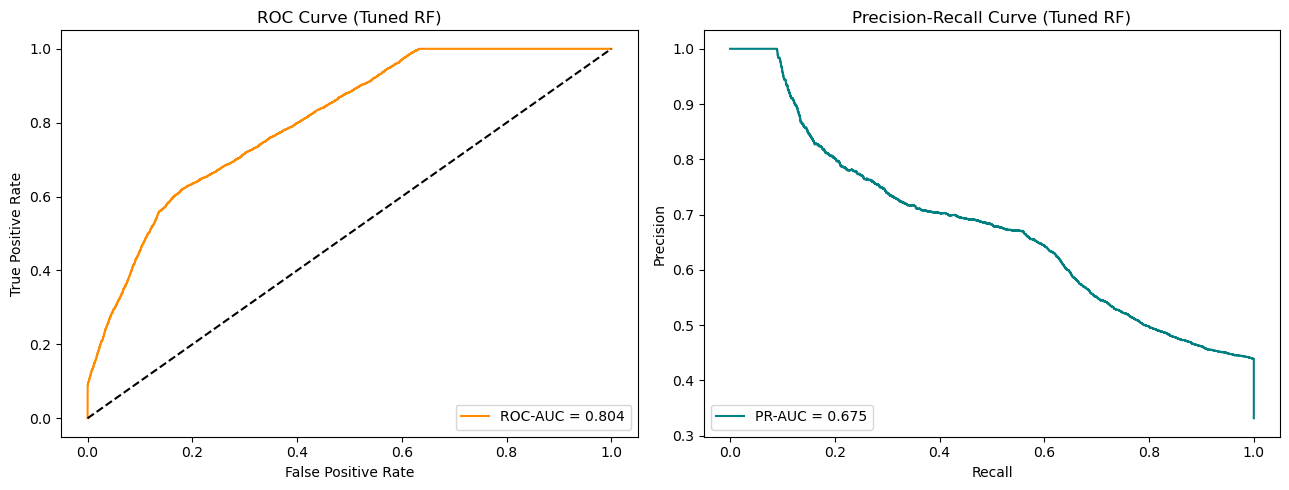


Best threshold by F1: 0.50
Best F1 at this threshold: 0.6243


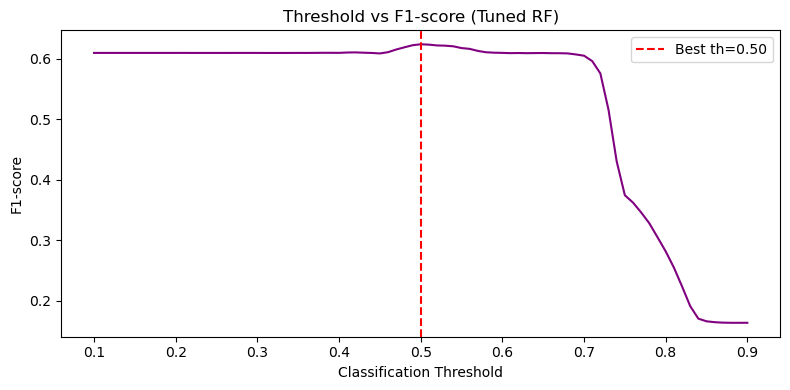

In [22]:
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

# Predictions from tuned model
y_pred_tuned = best_model.predict(X_test)
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

acc_t = accuracy_score(y_test, y_pred_tuned)
prec_t = precision_score(y_test, y_pred_tuned)
rec_t = recall_score(y_test, y_pred_tuned)
f1_t = f1_score(y_test, y_pred_tuned)
auc_t = roc_auc_score(y_test, y_proba_tuned)
ap_t = average_precision_score(y_test, y_proba_tuned)

print('Tuned Random Forest Performance')
print('-' * 40)
print(f'Accuracy : {acc_t:.4f}')
print(f'Precision: {prec_t:.4f}')
print(f'Recall   : {rec_t:.4f}')
print(f'F1-score : {f1_t:.4f}')
print(f'ROC-AUC  : {auc_t:.4f}')
print(f'PR-AUC   : {ap_t:.4f}')

print('\nClassification Report (Tuned):')
print(classification_report(y_test, y_pred_tuned, target_names=['No Churn', 'Churn']))

# ROC and PR curves
fpr, tpr, _ = roc_curve(y_test, y_proba_tuned)
pr, rc, _ = precision_recall_curve(y_test, y_proba_tuned)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, label=f'ROC-AUC = {auc_t:.3f}', color='darkorange')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('ROC Curve (Tuned RF)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

axes[1].plot(rc, pr, label=f'PR-AUC = {ap_t:.3f}', color='teal')
axes[1].set_title('Precision-Recall Curve (Tuned RF)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

# Threshold tuning to maximize F1-score
thresholds = np.arange(0.10, 0.91, 0.01)
f1_scores = []

for th in thresholds:
    preds = (y_proba_tuned >= th).astype(int)
    f1_scores.append(f1_score(y_test, preds))

best_idx = int(np.argmax(f1_scores))
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f'\nBest threshold by F1: {best_threshold:.2f}')
print(f'Best F1 at this threshold: {best_f1:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, color='purple')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best th={best_threshold:.2f}')
plt.title('Threshold vs F1-score (Tuned RF)')
plt.xlabel('Classification Threshold')
plt.ylabel('F1-score')
plt.legend()
plt.tight_layout()
plt.show()

## 11) Critical Analysis + Conclusion (For Report/Viva)

Key findings:
- Random Forest was trained and then improved with hyperparameter tuning.
- Evaluation included Accuracy, Precision, Recall, F1-score, ROC-AUC, and PR-AUC.
- A 4-model benchmark was added to compare algorithm behavior on common metrics.

How performance could be improved:
- Add feature engineering (e.g., interaction terms, tenure buckets, spending trends).
- Use class-imbalance strategies beyond class weights (SMOTE, threshold optimization by business cost).
- Run stronger hyperparameter search with wider ranges and nested CV.
- Evaluate calibration and cost-sensitive decision thresholds for deployment.

Limitations/future work:
- Current dataset is synthetic; external validation on a real public dataset is recommended.
- Model drift monitoring and periodic retraining should be planned for production usage.

Individual contribution section (copy to report):
- Include each member's role (data prep, modeling, tuning, evaluation/report, presentation).